# Matching a scalar dependence strength across six MTS families

Development validation: covariance mean **16.7%**, all MPI means **100.0%**, distribution summaries **100.0%**, and training-complete SPI–SPI **100.0%**; chance is **16.7%**. The strongest tested mean-vector readout scores **100.0%**. These comparisons do not imply that information is absent from the MPI marginals. **This experiment does not establish an advantage of SPI–SPI over the full MPI mean vector.**

The simplest baseline is the off-diagonal mean of the empirical covariance MPI,

$$b(X)=\frac{1}{M(M-1)}\sum_{i\ne j}\widehat{\operatorname{Cov}}(x_i,x_j).$$

Every channel is centered and scaled to unit empirical variance (divisor $T$), so this also equals mean signed Pearson correlation. Because positive and negative correlations can cancel, we additionally match $a(X)=\operatorname{mean}_{i\ne j}|r_{ij}|$. A scalar has only one informative dimension; its display is a classwise strip plot, not a two-dimensional PCA/UMAP. The comparison then progresses to all 289 p90 MPI means $m$, seven summaries per MPI (mean, SD, 10/25/50/75/90 percentiles), and signed Pearson SPI–SPI $z$.

All multi-statistic comparisons use the 289-SPI p90 subset, not the entire SPI catalogue. The six matched classes are VAR, Wave, CML, Kuramoto, shared-input Gaussian and shared-input Cauchy. Independent Gaussian and Cauchy recordings are separate zero-population-dependence controls, excluded from the six-class classifier. All recordings use $M=16$, $T=1000$: a practical common size inherited from the cached proof bank, yielding 240 ordered channel pairs (120 unique undirected pairs), not 240 independent observations. This size was not optimized to maximize separation.

In [1]:
from pathlib import Path
import sys, json
ROOT=Path.cwd().resolve()
while not (ROOT/'pyproject.toml').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import pandas as pd
from IPython.display import display, Image
RUN='pearson-strength-matched-261004'; STAGE='development'
RESULT=ROOT/'results/representation'/RUN/STAGE
metrics=pd.read_csv(RESULT/'metrics.csv')
display(metrics.round(3))

,method,n,BA,low,high,chance
0,mean,48,1.000,1.000,1.000,0.167
1,distribution,48,1.000,1.000,1.000,0.167
2,z,48,1.000,1.000,1.000,0.167
3,z_validity,48,0.417,0.354,0.500,0.167
4,b,48,0.167,0.167,0.167,0.167
5,pearson_two,48,0.167,0.167,0.167,0.167
6,z_complete,48,1.000,1.000,1.000,0.167
7,z_standard,48,1.000,1.000,1.000,0.167
8,mean_complete,48,1.000,1.000,1.000,0.167
9,z_shuffled_complete,48,0.125,0.083,0.167,0.167


## What is normalized, and why?

Each block draws a signed target $b_j\sim U(.003,.007)$ and an absolute target $a_j\sim U(.065,.075)$, shared by all six classes. Targets vary across recordings while their distribution is identical across classes. Their low positive ranges were selected for feasibility across the cached development families, not from full-catalogue separation outcomes. They are engineered experimental settings, not universal physical constants.

For the four coupled dynamical families, add independent Gaussian observation noise and tune its scale to $a_j$, then standardize each channel. For the noise variants, tune the shared-input mixture $(1-g)\epsilon_i+g\ell_iF$, with heterogeneous positive loadings, to the same target. The innovations and common input are Gaussian or Cauchy according to class. Enumerating channel polarities $s_i\in\{-1,+1\}$ then selects the closest signed target. Polarity changes preserve absolute pairwise correlations and each channel's autocorrelation; additive observation noise does not preserve every aspect of the original dynamics.

This is **data-conditioned observation-space normalization of two explicit summaries**, not equality of universal physical or causal coupling. The noise classes acquire dependence through shared inputs, without direct channel-to-channel coupling. Cauchy variables have [undefined population variance](https://itl.nist.gov/div898/handbook/eda/section3/eda3663.htm); their covariance matching here is strictly a finite-recording operation. No MPI entries are adjusted after computation. The matched scalar baseline is expected to fail by construction; the empirical question is whether useful distinctions survive in the other representations.

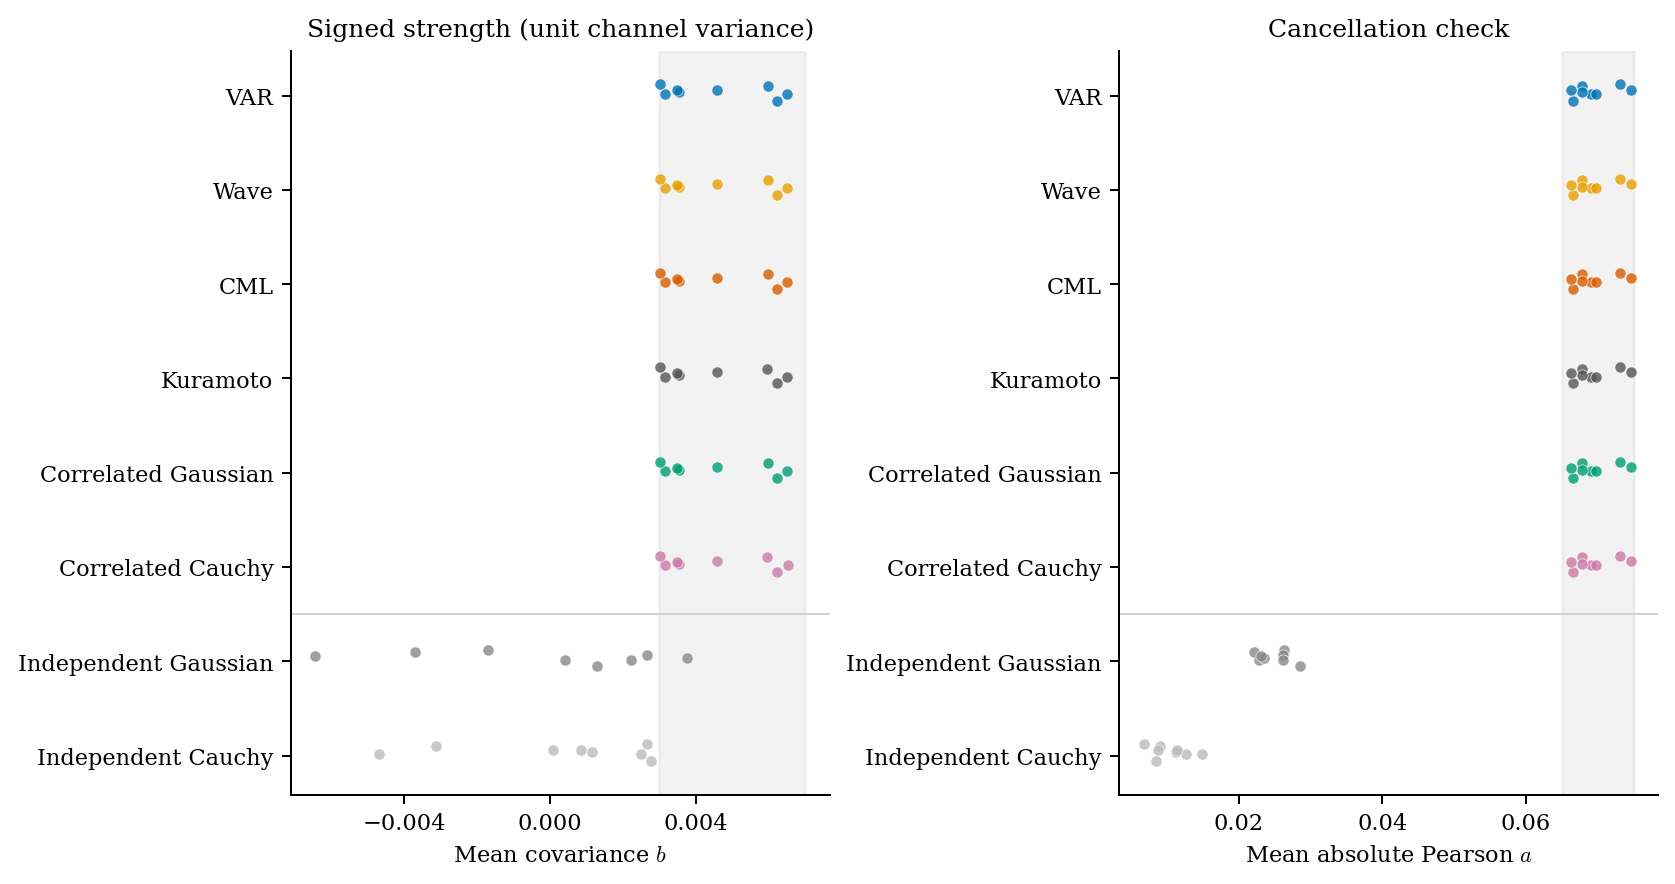

,mean_channel_lag1,mean_channel_fourth_moment
label,,
CML,-0.069,2.995
Correlated Cauchy,-0.002,480.439
Correlated Gaussian,0.005,3.006
Independent Cauchy,-0.002,537.007
Independent Gaussian,0.006,3.017
Kuramoto,0.327,2.833
VAR,0.472,2.968
Wave,0.115,3.003


In [2]:
display(Image(filename=str(RESULT/'figures/matched-strength.png')))
display(pd.read_csv(RESULT/'observation-diagnostics.csv').groupby('label')[['mean_channel_lag1','mean_channel_fourth_moment']].median().round(3))

The table gives medians across evaluation recordings of two raw-data diagnostics: mean channel lag-one autocovariance and mean standardized fourth moment. These describe remaining temporal and channel-distribution differences; they are not fitted alternatives or population moments for Cauchy data. Substantial residual differences would limit attribution of class separation specifically to cross-channel dependence character. Both signed and absolute strength targets can match while these properties differ.

## Frozen comparison and fixed embeddings

Development blocks 0–15 train, blocks 16–23 validate; blocks 24–47 are held until the development gate. There are six matched recordings and two independent controls per block. Coupled development records reuse previously examined raw inputs and are explicitly exploratory; held coupled inputs use fresh generator seeds. Shared target/noise blocks stay together across splits. Final fitting uses all development blocks, then evaluates the untouched held blocks.

Feature selection, imputation, scaling and PCA use training recordings only. Means/distributions are standardized, clipped at five SD and reduced to 20 PCs. The primary $z$ readout centers without rescaling, retaining only features finite in every training recording, followed by 20 PCs. All use logistic regression with $C=1$. Full-vector linear, RBF and tree mean controls, standardized $z$, estimator-validity-only features and independently edge-shuffled $z$ are retained. The shuffle preserves each MPI's marginal values but destroys their alignment; it is a representation diagnostic and need not describe a realizable MTS.

PCA/UMAP are fit on the training projections and transform evaluation points; UMAP fixes 30 neighbors, minimum distance .1 and seed 261003. Every evaluation point is shown. Classifier results use the full retained representation, not the plotted two coordinates. Conditional 95% intervals resample paired blocks 5,000 times while keeping the fitted models fixed, so they omit training and experimental-design uncertainty. At perfect accuracy these empirical bootstrap intervals degenerate to a point; that is not evidence of zero generalization uncertainty.

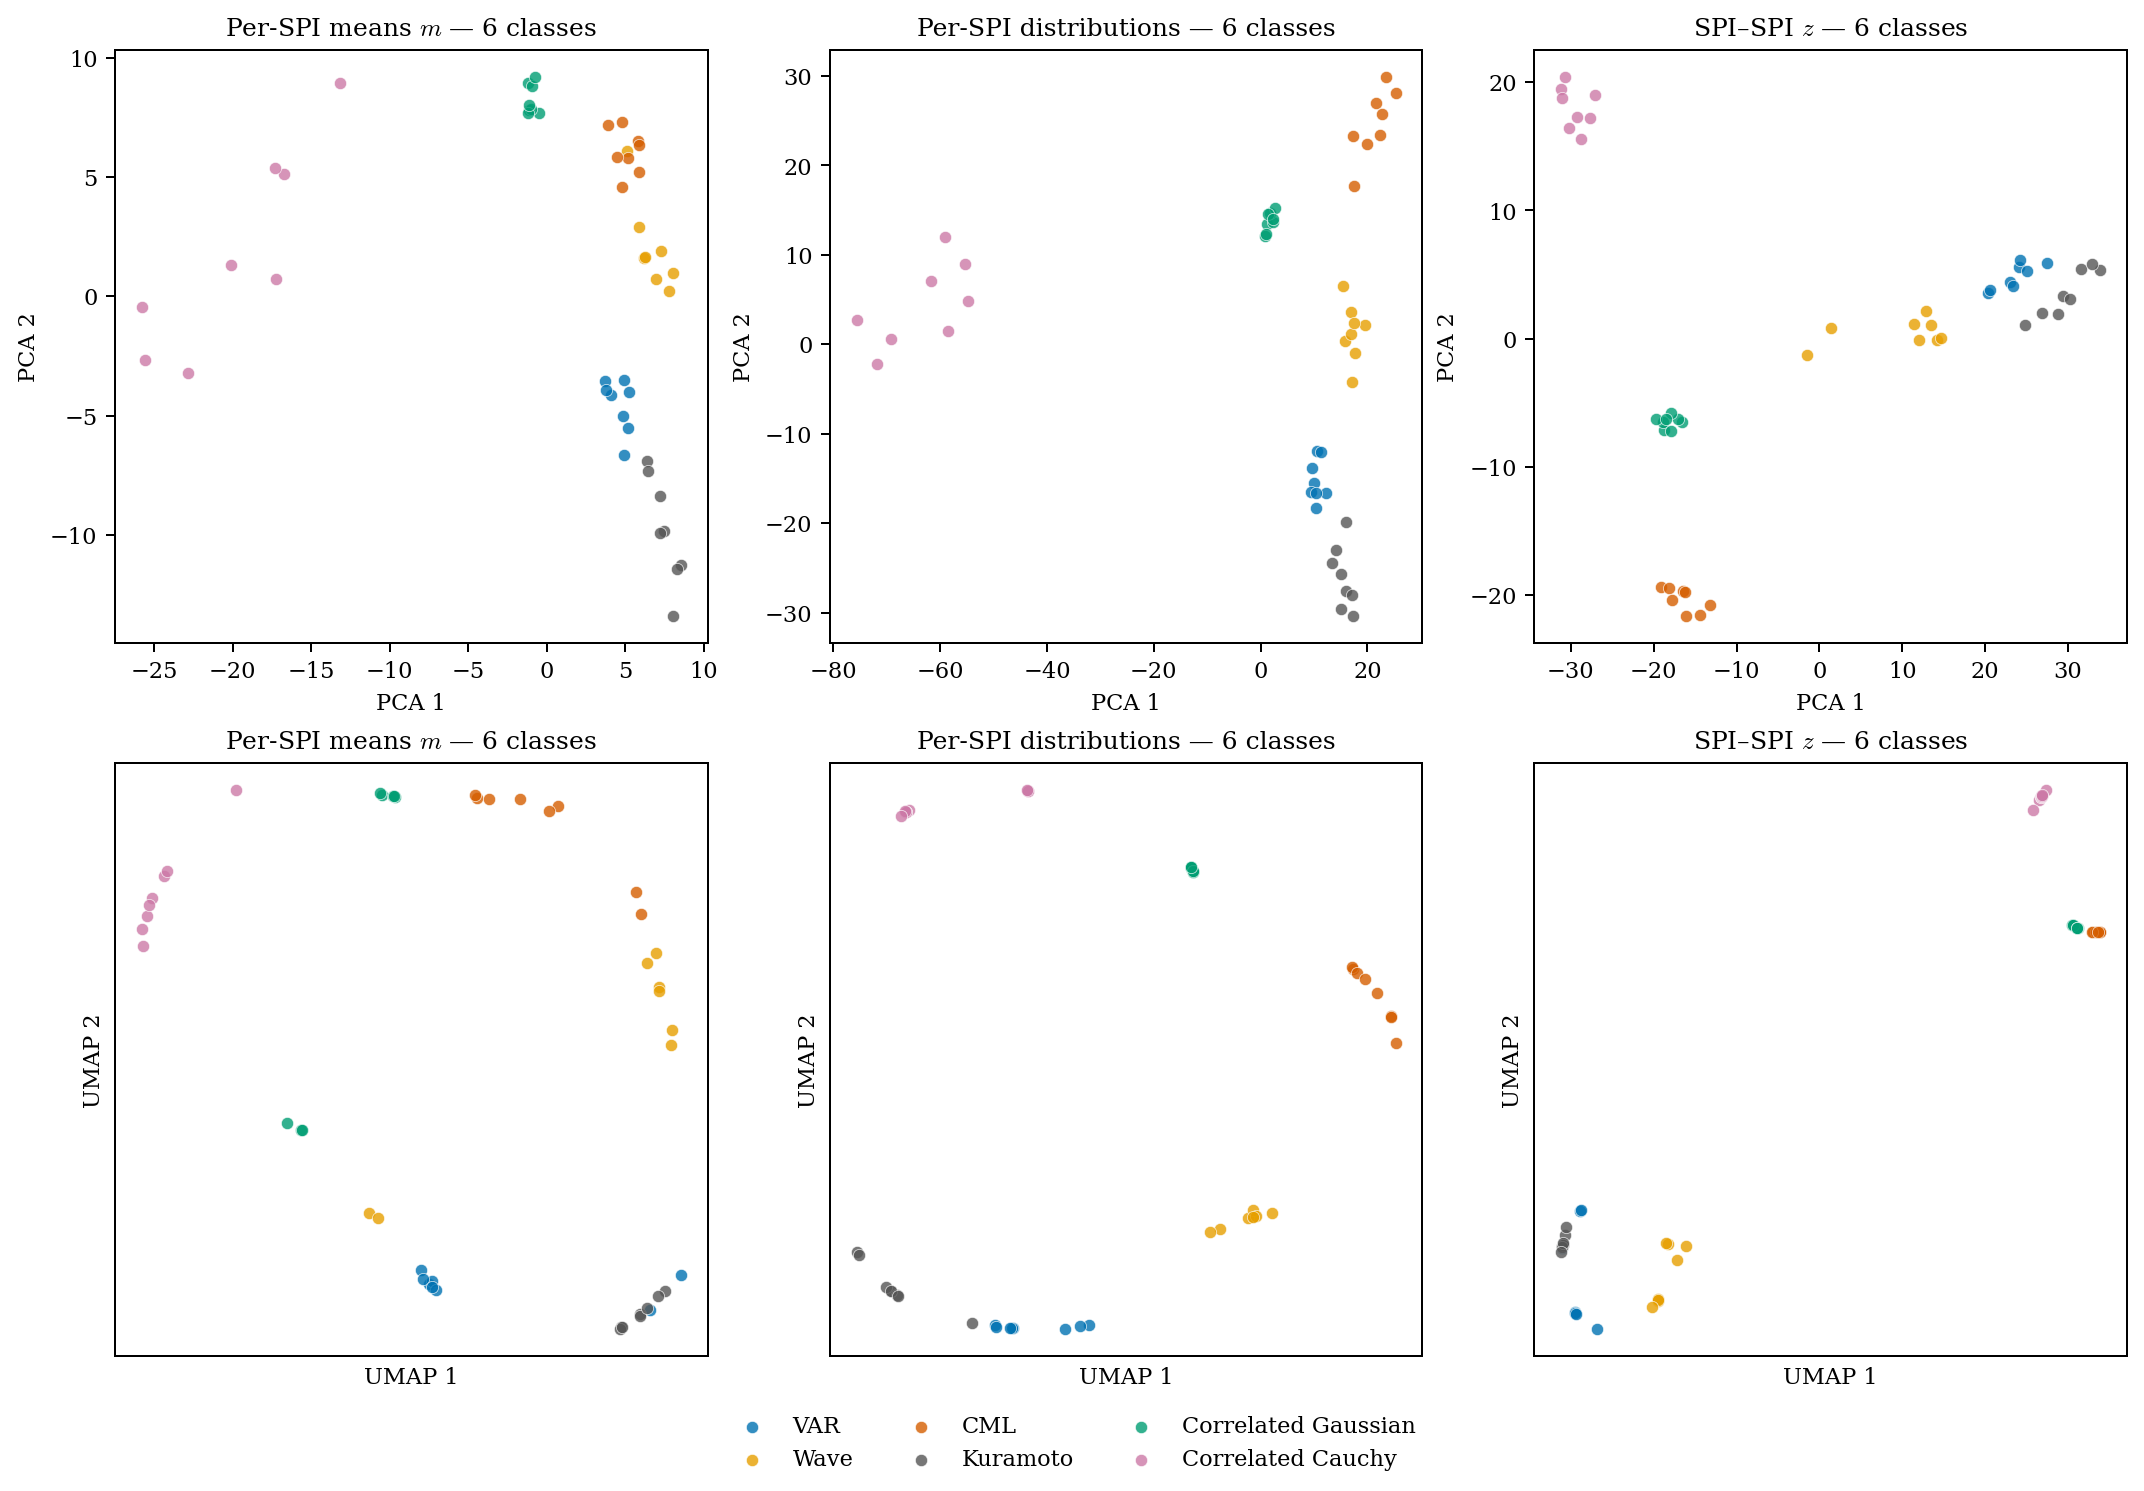

,comparison,difference,low,high
0,z_complete - b,0.833,0.833,0.833
1,z_complete - b_RBF,0.833,0.833,0.833
2,z_complete - b_full,0.833,0.833,0.833
3,z_complete - b_trees,0.833,0.833,0.833
4,z_complete - distribution,0.000,0.000,0.000
5,z_complete - mean,0.000,0.000,0.000
6,z_complete - mean_RBF,0.000,0.000,0.000
7,z_complete - mean_complete,0.000,0.000,0.000
8,z_complete - mean_full,0.000,0.000,0.000
9,z_complete - mean_trees,0.000,0.000,0.000


In [3]:
display(Image(filename=str(RESULT/'figures/baseline-hierarchy.png')))
display(pd.read_csv(RESULT/'paired.csv').round(3))

Independent controls are projected into the same training-fitted mean and SPI–SPI spaces below; they do not influence those fits. Larger outlined diamonds/triangles denote independent Gaussian/Cauchy recordings, and faded circles show the six matched classes. These are a diagnostic view, not an additional eight-class accuracy claim. The table reports missing selected features, imputed from training medians; these can influence control positions even though the primary matched-class z evaluation has no missing features. Positions in two PCs alone cannot determine which aspect of the data drives separation.

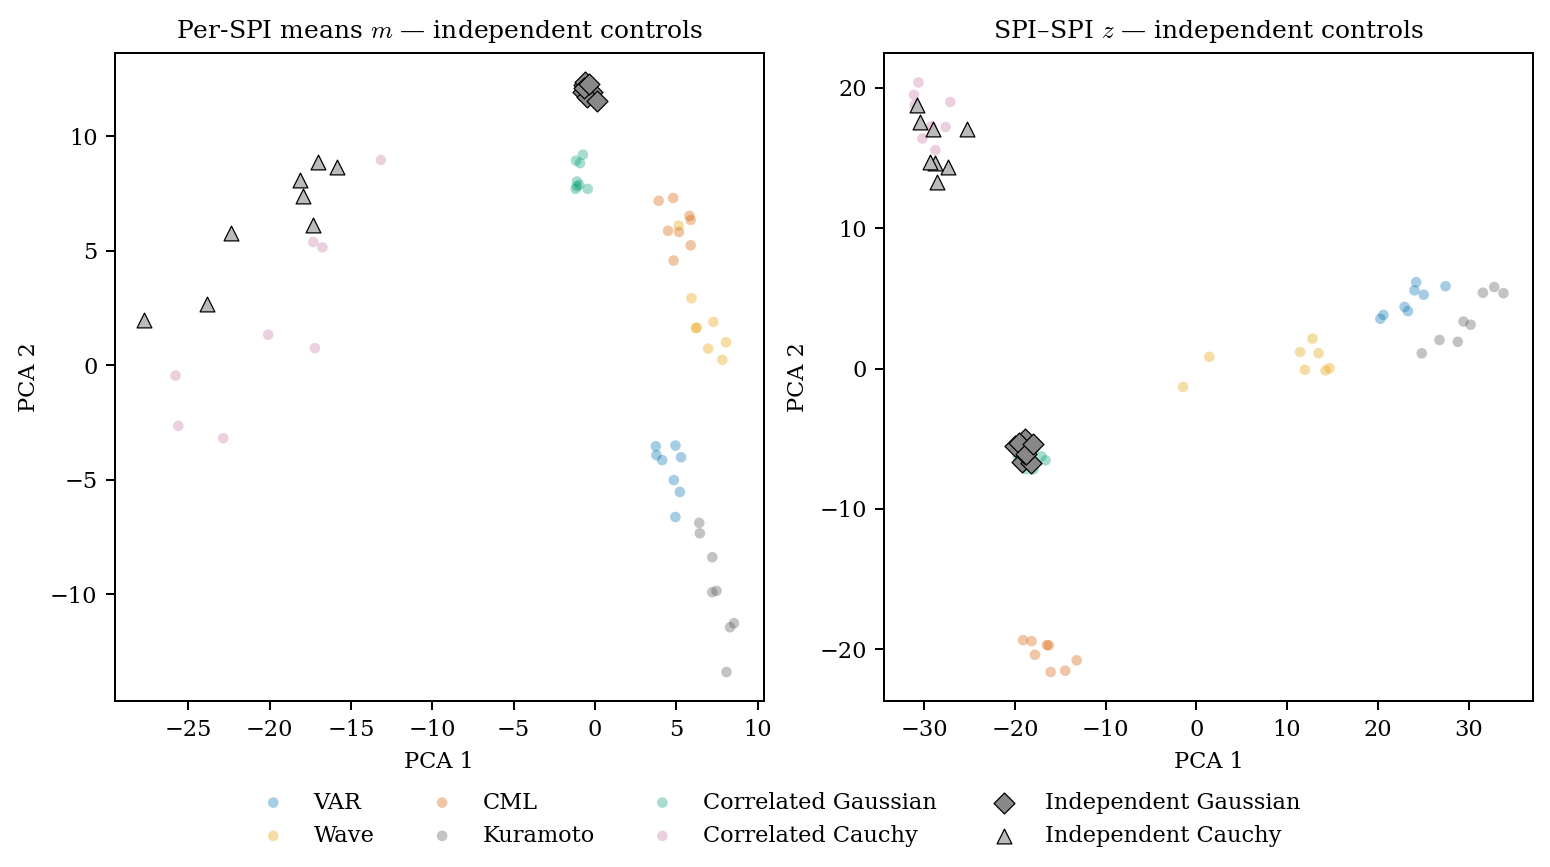

,method,label,mean_missing,max_missing
0,mean,Gaussian-independent,0.000,0.000
1,mean,Cauchy-independent,0.000,0.000
2,z,Gaussian-independent,0.028,0.032
3,z,Cauchy-independent,0.016,0.032


In [4]:
display(Image(filename=str(RESULT/'figures/independent-controls.png')))
display(pd.read_csv(RESULT/'control-projection-validity.csv').round(4))

## Interpretation and limits

Failure of $b$ with successful $z$ establishes information beyond average signed covariance under this normalization. Matching absolute correlation makes this stronger than a cancellation-only demonstration. It does not show that full SPI means or distributions are blind to character: their average detector responses can themselves distinguish temporal structure, non-Gaussianity and other properties. Strong $m$ must be credited, rather than treated as a failed baseline to conceal.

SPI–SPI measures how notions of dependence vary together across channel pairs. It is invariant to positive affine transformations of each SPI profile, not to arbitrary changes in generator coupling or measurement noise. Separation here may reflect temporal structure, channel distributions, topology, estimator behavior and their combinations; it is not an identified axis of pure nonlinearity or causal interaction. Independent Gaussian/Cauchy controls illustrate why distinguishing MTS families alone does not prove different cross-channel coupling. Validity and shuffled-edge controls constrain, but do not eliminate, these interpretations.

Earlier negative evidence remains in the all-proof native-gain, band-swap and factor-parity notebooks. Native gain matching did not make the full mean vector uninformative; the Gaussian factor construction gave only partial full-catalogue gains. This experiment addresses the simpler scalar-strength claim and must not be presented as resolving that stronger target.

In [5]:
analysis=json.loads((RESULT/'analysis.json').read_text())
display(pd.DataFrame(analysis['diagnostics']).T)
print('Frozen numerical criteria:',analysis['development_gate'])

,selected_features,components,validation_selected_missing_fraction
mean,271.0,20.0,0.000000
distribution,1907.0,20.0,0.000000
z,31685.0,20.0,0.001291
z_validity,8783.0,20.0,0.000000
b,1.0,1.0,0.000000
pearson_two,2.0,2.0,0.000000
z_complete,29182.0,20.0,0.000000
z_standard,31685.0,20.0,0.001291
mean_complete,265.0,20.0,0.000000
z_shuffled_complete,31375.0,20.0,0.000000


Frozen numerical criteria: {'covariance_mean_weak': True, 'signed_absolute_weak': True, 'z_detectable': True, 'all_pass': True}


Protocol and source bindings: `configs/analysis/pearson-strength-matched-261004.yaml` and `configs/analysis/pearson-strength-matched-261004-bindings.yaml`. Raw inputs and MPI provenance are recorded in the manifest and execution receipt; audited source hashes are in this stage’s `sources.json`. Figures and evaluation are reproduced from saved features without recomputing SPIs. Stage: **development**. Frozen numerical criteria all passed: **True**.